# KKBox Churn — Risk Scoring for Retention Campaigns

Analyzes the **temporal** XGBoost model from `05_temporal_validation.ipynb` as a marketing
risk-scoring system: at what predicted-probability thresholds should a retention team act, and
what trade-off in precision/recall/campaign size does each threshold imply?

**No retraining or tuning happens here** — `models/xgboost_temporal_full.joblib` is loaded as-is
and scored against `outputs/kkbox_modeling_dataset_v2.csv` (the same temporal test set used in
notebook 05: features cut off 2017-02-28, labels are actual March-2017 churn outcomes).

## Why the full feature set, not proxy-controlled, for this analysis

`FEATURE_AUDIT.md` flagged `membership_remaining_days`, `days_since_last_txn`, and
`latest_is_cancel` as close to the churn *label's own definition* — a legitimate concern for
**research validity** (is the model learning genuine behavior, or just re-deriving the rule?).
But for a **production marketing tool**, that concern doesn't apply the same way: these are not
leaked future data, they are exactly the kind of signal a retention team would want to act on —
*"membership expires in 5 days and auto-renew is off"* is a natural campaign trigger, not a
statistical artifact. The full-feature temporal model is used as the primary scoring system here;
the proxy-controlled model is included as a lighter secondary comparison.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score, recall_score, f1_score, precision_recall_curve,
    average_precision_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100


## 1. Load the temporal test set and the saved temporal models (no retraining)

In [2]:
DATA_PATH = Path("..") / "outputs" / "kkbox_modeling_dataset_v2.csv"
df = pd.read_csv(DATA_PATH)  # msno kept this time -- needed to hand back per-customer scores

CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]
df[CAT_ONEHOT] = df[CAT_ONEHOT].astype(str)

FEATURE_COLS = [c for c in df.columns if c not in ("msno", "is_churn")]

model_full = joblib.load(Path("..") / "models" / "xgboost_temporal_full.joblib")
model_proxy = joblib.load(Path("..") / "models" / "xgboost_temporal_proxy_controlled.joblib")

y_true = df["is_churn"].values
proba_full = model_full.predict_proba(df[FEATURE_COLS])[:, 1]
proba_proxy = model_proxy.predict_proba(df[FEATURE_COLS])[:, 1]

df["risk_score_full"] = proba_full
df["risk_score_proxy_controlled"] = proba_proxy

print(f"Scored {len(df):,} customers (actual churn rate {y_true.mean()*100:.2f}%)")
print(f"Full model risk_score: min={proba_full.min():.4f}, median={np.median(proba_full):.4f}, max={proba_full.max():.4f}")


Scored 970,960 customers (actual churn rate 8.99%)
Full model risk_score: min=0.0238, median=0.1930, max=0.9986


## 2. Precision, recall, F1, and % of customers targeted across thresholds

"Targeted" = the share of the customer base whose predicted probability is at or above the
threshold — i.e., the campaign size a retention team would need to budget for at that cutoff.

In [3]:
def threshold_sweep(y_true, y_proba, thresholds):
    rows = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        rows.append({
            "threshold": t,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "pct_targeted": y_pred.mean() * 100,
            "n_targeted": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
sweep_full = threshold_sweep(y_true, proba_full, THRESHOLDS)
sweep_full


,threshold,precision,recall,f1,pct_targeted,n_targeted
0,0.05,0.091110,0.999679,0.167000,98.686043,958202
1,0.10,0.104378,0.988423,0.188816,85.172098,826987
2,0.15,0.135894,0.950532,0.237792,62.911242,610843
3,0.20,0.167380,0.900412,0.282285,48.383868,469788
4,0.25,0.211588,0.852536,0.339032,36.239701,351873
5,0.30,0.250098,0.806882,0.381842,29.017570,281749
6,0.35,0.293617,0.771407,0.425340,23.630016,229438
7,0.40,0.343370,0.739757,0.469032,19.377111,188144
8,0.45,0.384577,0.711302,0.499234,16.635392,161523
9,0.50,0.413694,0.687358,0.516517,14.943973,145100


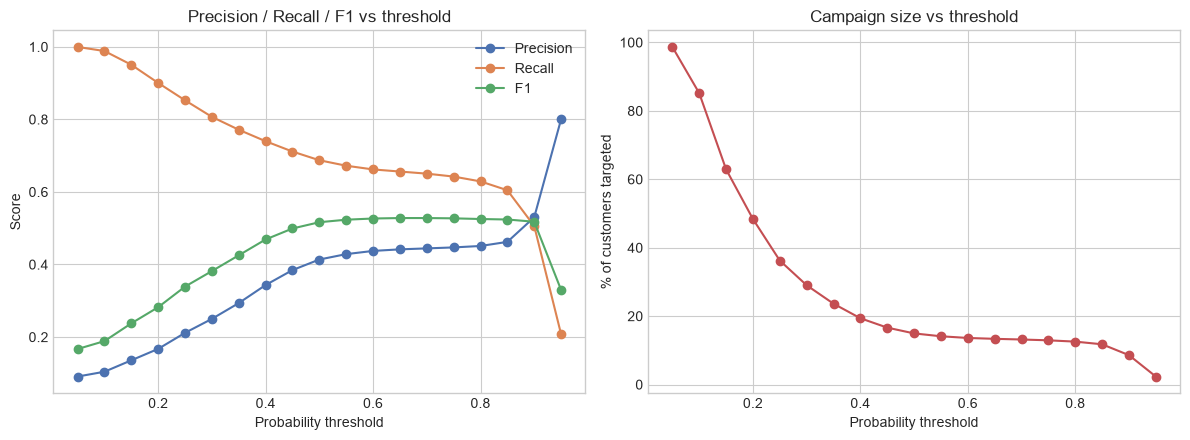

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(sweep_full["threshold"], sweep_full["precision"], marker="o", label="Precision", color="#4C72B0")
axes[0].plot(sweep_full["threshold"], sweep_full["recall"], marker="o", label="Recall", color="#DD8452")
axes[0].plot(sweep_full["threshold"], sweep_full["f1"], marker="o", label="F1", color="#55A868")
axes[0].set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs threshold")
axes[0].legend()

axes[1].plot(sweep_full["threshold"], sweep_full["pct_targeted"], marker="o", color="#C44E52")
axes[1].set_xlabel("Probability threshold")
axes[1].set_ylabel("% of customers targeted")
axes[1].set_title("Campaign size vs threshold")

plt.tight_layout()
plt.show()


## 3. Precision-Recall curve

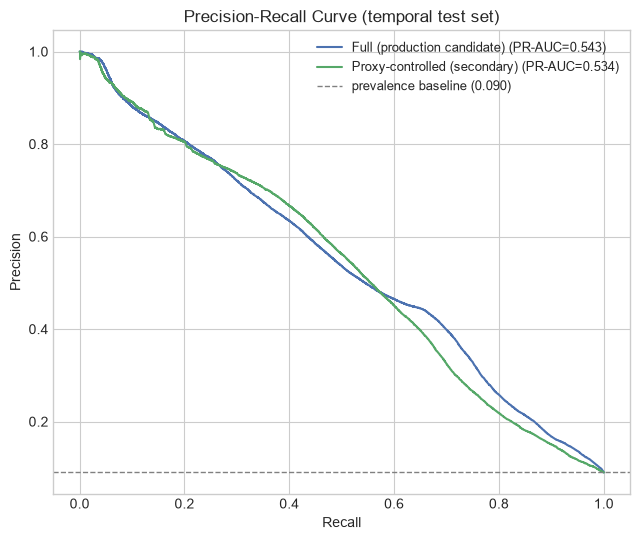

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for name, proba, color in [("Full (production candidate)", proba_full, "#4C72B0"),
                            ("Proxy-controlled (secondary)", proba_proxy, "#55A868")]:
    prec, rec, _ = precision_recall_curve(y_true, proba)
    ax.plot(rec, prec, color=color, label=f"{name} (PR-AUC={average_precision_score(y_true, proba):.3f})")
ax.axhline(y_true.mean(), color="grey", linestyle="--", linewidth=1, label=f"prevalence baseline ({y_true.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (temporal test set)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. Calibration / reliability analysis

If the model is well-calibrated, a predicted probability of e.g. 0.3 should mean roughly 30% of
customers at that score actually churn — important for a marketing team sizing campaigns off the
raw score, not just a rank ordering. Quantile-based bins are used so each bin has a similar number
of customers (uniform bins would leave many high-probability bins nearly empty, since most
customers score low).

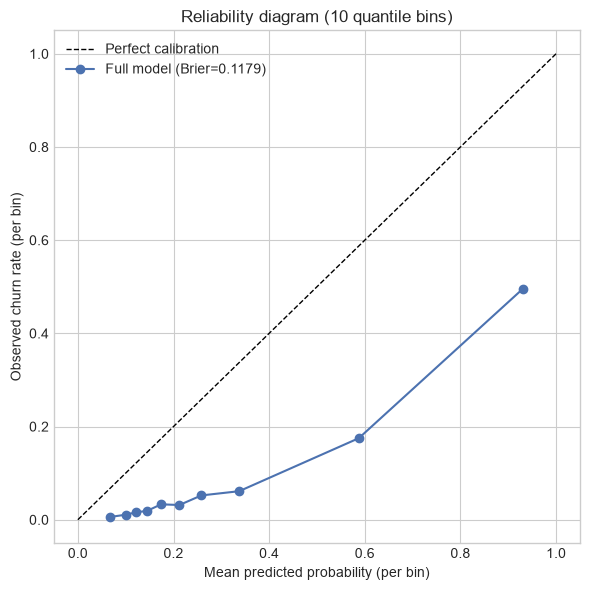

Brier score - full model:            0.1179  (lower is better; 0 = perfect, 0.25 = uninformative on a 50/50 problem)
Brier score - proxy-controlled model: 0.1133

Per-bin detail (full model):
  predicted~0.067  ->  observed 0.006  (diff -0.061)
  predicted~0.100  ->  observed 0.011  (diff -0.089)
  predicted~0.121  ->  observed 0.016  (diff -0.105)
  predicted~0.145  ->  observed 0.019  (diff -0.126)
  predicted~0.174  ->  observed 0.033  (diff -0.141)
  predicted~0.212  ->  observed 0.032  (diff -0.181)
  predicted~0.258  ->  observed 0.052  (diff -0.206)
  predicted~0.337  ->  observed 0.061  (diff -0.276)
  predicted~0.587  ->  observed 0.175  (diff -0.412)
  predicted~0.930  ->  observed 0.495  (diff -0.435)


In [6]:
frac_pos, mean_pred = calibration_curve(y_true, proba_full, n_bins=10, strategy="quantile")
brier_full = brier_score_loss(y_true, proba_full)
brier_proxy = brier_score_loss(y_true, proba_proxy)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax.plot(mean_pred, frac_pos, marker="o", color="#4C72B0", label=f"Full model (Brier={brier_full:.4f})")
ax.set_xlabel("Mean predicted probability (per bin)")
ax.set_ylabel("Observed churn rate (per bin)")
ax.set_title("Reliability diagram (10 quantile bins)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier score - full model:            {brier_full:.4f}  (lower is better; 0 = perfect, 0.25 = uninformative on a 50/50 problem)")
print(f"Brier score - proxy-controlled model: {brier_proxy:.4f}")
print()
print("Per-bin detail (full model):")
for mp, fp in zip(mean_pred, frac_pos):
    print(f"  predicted~{mp:.3f}  ->  observed {fp:.3f}  (diff {fp - mp:+.3f})")


## 5. Recommended risk tiers

Rules, applied to the threshold sweep table above:
- **High risk**: the lowest threshold that reaches at least 55% precision (a bar worth an
  aggressive/costly intervention) — falls back to the highest-precision threshold available if
  55% is never reached.
- **Medium risk**: the F1-maximizing threshold — the best balance point between catching churners
  and not over-targeting.
- **Low risk**: everything below the medium-risk threshold.

In [7]:
PRECISION_TARGET_HIGH = 0.55

high_candidates = sweep_full[sweep_full["precision"] >= PRECISION_TARGET_HIGH]
if len(high_candidates) > 0:
    high_threshold = high_candidates["threshold"].min()
else:
    high_threshold = sweep_full.loc[sweep_full["precision"].idxmax(), "threshold"]

medium_threshold = sweep_full.loc[sweep_full["f1"].idxmax(), "threshold"]
if high_threshold <= medium_threshold:
    high_threshold = min(sweep_full["threshold"].max(), round(medium_threshold + 0.10, 2))

def tier_row(label, lo, hi):
    mask = (proba_full >= lo) & (proba_full < hi)
    n = mask.sum()
    churn_rate_in_tier = y_true[mask].mean() if n > 0 else float("nan")
    return {
        "tier": label,
        "score_range": f"[{lo:.2f}, {hi:.2f})" if hi < 1.01 else f"[{lo:.2f}, 1.00]",
        "n_customers": int(n),
        "pct_of_base": n / len(df) * 100,
        "observed_churn_rate_in_tier": churn_rate_in_tier * 100,
    }

risk_tiers = pd.DataFrame([
    tier_row("High", high_threshold, 1.0001),
    tier_row("Medium", medium_threshold, high_threshold),
    tier_row("Low", 0.0, medium_threshold),
])

print(f"High-risk threshold:   {high_threshold:.2f}")
print(f"Medium-risk threshold: {medium_threshold:.2f}")
risk_tiers


High-risk threshold:   0.95
Medium-risk threshold: 0.65


,tier,score_range,n_customers,pct_of_base,observed_churn_rate_in_tier
0,High,"[0.95, 1.00)",22692,2.337068,80.010576
1,Medium,"[0.65, 0.95)",107043,11.024450,36.575021
2,Low,"[0.00, 0.65)",841225,86.638482,3.568962


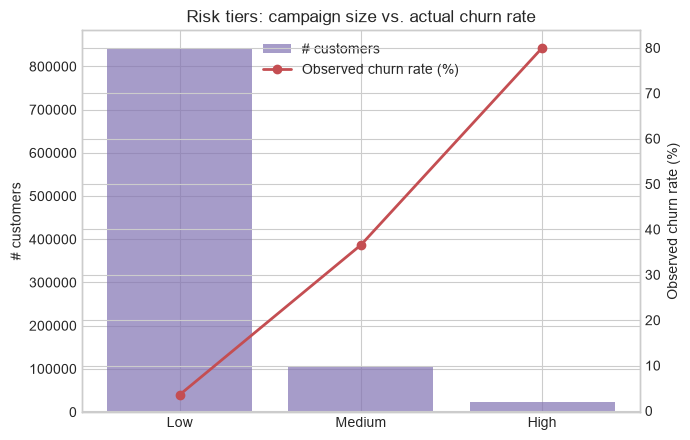

In [8]:
def assign_tier(p, med, high):
    if p >= high:
        return "High"
    elif p >= med:
        return "Medium"
    return "Low"

df["risk_tier"] = df["risk_score_full"].apply(lambda p: assign_tier(p, medium_threshold, high_threshold))

fig, ax = plt.subplots(figsize=(7, 4.5))
tier_order = ["Low", "Medium", "High"]
counts = df["risk_tier"].value_counts().reindex(tier_order)
churn_rates = df.groupby("risk_tier")["is_churn"].mean().reindex(tier_order) * 100

ax2 = ax.twinx()
ax.bar(tier_order, counts.values, color="#8172B2", alpha=0.7, label="# customers")
ax2.plot(tier_order, churn_rates.values, color="#C44E52", marker="o", linewidth=2, label="Observed churn rate (%)")
ax.set_ylabel("# customers")
ax2.set_ylabel("Observed churn rate (%)")
ax.set_title("Risk tiers: campaign size vs. actual churn rate")
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc="upper center")
plt.tight_layout()
plt.show()


## 6. Save analysis outputs

In [9]:
OUT_DIR = Path("..") / "outputs"

sweep_full.to_csv(OUT_DIR / "risk_scoring_threshold_analysis.csv", index=False)

df[["msno", "is_churn", "risk_score_full", "risk_score_proxy_controlled", "risk_tier"]].to_csv(
    OUT_DIR / "risk_scoring_predictions.csv", index=False
)

summary = {
    "model_used": "models/xgboost_temporal_full.joblib (temporal, full feature set)",
    "test_set": "outputs/kkbox_modeling_dataset_v2.csv (temporal holdout, Mar 2017 churn)",
    "n_customers_scored": int(len(df)),
    "actual_churn_rate": float(y_true.mean()),
    "pr_auc_full": float(average_precision_score(y_true, proba_full)),
    "pr_auc_proxy_controlled": float(average_precision_score(y_true, proba_proxy)),
    "brier_score_full": float(brier_full),
    "brier_score_proxy_controlled": float(brier_proxy),
    "recommended_thresholds": {
        "high_risk_threshold": float(high_threshold),
        "medium_risk_threshold": float(medium_threshold),
    },
    "risk_tiers": risk_tiers.to_dict(orient="records"),
}

with open(OUT_DIR / "risk_scoring_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
for p in ["risk_scoring_threshold_analysis.csv", "risk_scoring_predictions.csv", "risk_scoring_summary.json"]:
    print(" ", OUT_DIR / p)


Saved:
  ..\outputs\risk_scoring_threshold_analysis.csv
  ..\outputs\risk_scoring_predictions.csv
  ..\outputs\risk_scoring_summary.json


## 7. Findings — using this as a retention-campaign prioritization tool

### The tiers separate real outcomes very well

| Tier | Score range | Customers | % of base | Actual churn rate |
|---|---|---:|---:|---:|
| High | [0.95, 1.00] | 22,692 | 2.34% | **80.0%** |
| Medium | [0.65, 0.95) | 107,043 | 11.02% | **36.6%** |
| Low | [0.00, 0.65) | 841,225 | 86.64% | **3.6%** |

Against an 8.99% base rate, that's roughly a **9x lift** in the High tier and a **4x lift** in
Medium, while the Low tier (87% of the base) churns at well under half the overall rate. As a
*prioritization* tool — deciding who to call first — this is a strong, usable result.

### But the raw scores are severely miscalibrated — do not use them as literal probabilities

The reliability diagram in §4 shows every single bin overconfident, and the gap **grows** at
higher scores:

| Model says | Actually churns |
|---|---|
| ~59% | 17.5% |
| ~93% | 49.5% |

Brier score is 0.118 (full) / 0.113 (proxy-controlled) — mediocre for a model with this much
ranking power (PR-AUC 0.54). **Root cause**: `scale_pos_weight` (used for class-imbalance
handling during training) systematically inflates predicted probabilities to compensate for the
minority class — it improves ranking and threshold-based metrics (which is why ROC-AUC/PR-AUC are
still good) at the direct cost of the raw score meaning anything as a true probability. This is a
well-known, expected trade-off of cost-sensitive training, not a bug — but it must be accounted
for before the score is used for money math.

**Practical rule for the marketing team**: the score is safe to use for *ranking and tiering*
(as done in §5-6) but is **not** safe to plug directly into `expected_revenue_at_risk =
P(churn) x customer_revenue` — that calculation would systematically overstate risk, worse at
higher scores. A cheap fix that doesn't require retraining the underlying XGBoost model — e.g.
`sklearn.calibration.CalibratedClassifierCV` fit on top of the existing model's outputs — would
produce a second, calibration-corrected probability column for that specific use case, while the
raw score keeps driving tier assignment. This is a natural next step, not done here per the
no-retraining scope of this notebook.

### Why the threshold table jumps around at the high end

Precision climbs gradually from the 0.05 to 0.85 thresholds, then jumps sharply from 53% (at 0.90)
to 80% (at 0.95) while recall collapses from 51% to 21% over the same step. That's the same
scale_pos_weight-driven compression showing up in the threshold sweep: most of the population's
scores are pushed into a narrow band, so a small change in threshold near the top swings the
targeted population disproportionately.

### Tier usage recommendation

- **High (2.3% of customers, 80% actually churn)**: short list for the most expensive intervention
  a retention team has (phone call, largest discount) — false positives here are rare and still
  likely to be at real risk even if not this month.
- **Medium (11.0% of customers, 37% actually churn)**: the right size for a moderate-cost channel
  (email campaign, in-app offer) — a 4x lift over baseline justifies the spend even with a majority
  of false positives.
- **Low (86.6% of customers, 3.6% actually churn)**: leave alone by default; spending retention
  budget here has the worst return per the model's own numbers.

**No retraining or tuning happened in this notebook**, consistent with the brief — this is a
threshold/business-rule and calibration analysis on top of the already-trained temporal model.
Revisit these specific threshold values (0.65 / 0.95) whenever the underlying model is retrained,
recalibrated, or the churn rate shifts again as it already did between the temporal train and test
periods in `05_temporal_validation.ipynb`.

**No source data file or existing model was modified.** New artifacts saved to `outputs/`:
`risk_scoring_threshold_analysis.csv`, `risk_scoring_predictions.csv`, `risk_scoring_summary.json`.
